# Principia x Creamy x Sallve: interesse de busca por marcas nativas digitais de skincare

### 1 - Como evoluiu o interesse médio nas buscas do Google por Creamy, Principia e Sallve ao longo do período analisado?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/analise_interesse.csv")
df

,Time,Creamy,PRINCIPIA,Sallve
0,2020-01-01,4,1,2
1,2020-02-01,4,1,2
2,2020-03-01,5,1,2
3,2020-04-01,11,1,3
4,2020-05-01,11,2,5
...,...,...,...,...
76,2026-05-01,44,78,13
77,2026-06-01,47,73,13
78,2026-07-01,55,92,16
79,2026-08-01,51,100,15


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Time       81 non-null     str  
 1   Creamy     81 non-null     int64
 2   PRINCIPIA  81 non-null     int64
 3   Sallve     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.7 KB


In [4]:
df = df.rename(columns={
    'Time': 'Data',
    'PRINCIPIA' : "Principia"
})


In [5]:
df['Data'] = pd.to_datetime(df['Data'], format = "%Y-%m-%d")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Data       81 non-null     datetime64[us]
 1   Creamy     81 non-null     int64         
 2   Principia  81 non-null     int64         
 3   Sallve     81 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 2.7 KB


In [7]:
df['ano'] = df['Data'].dt.year


In [8]:
media_ano = (
    df.groupby("ano")
    [["Creamy", "Principia", "Sallve"]]
    .mean()
)

media_ano

,Creamy,Principia,Sallve
ano,,,
2020,8.416667,1.833333,4.416667
2021,10.666667,6.333333,6.500000
2022,11.083333,12.916667,7.833333
2023,22.416667,37.416667,10.750000
2024,39.500000,69.416667,13.166667
2025,42.583333,69.583333,14.583333
2026,47.222222,84.111111,13.777778


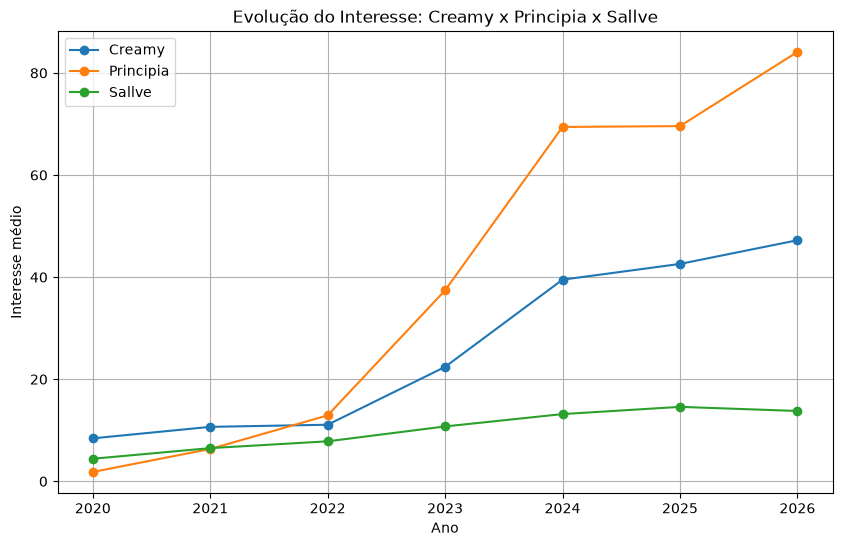

In [9]:
media_ano.plot(kind="line" , marker="o", figsize = (10,6))

plt.title("Evolução do Interesse: Creamy x Principia x Sallve")

plt.xlabel("Ano")
plt.ylabel("Interesse médio")
plt.grid(True)
plt.show()

As três marcas cresceram ao longo do período, mas com padrões diferentes. A Principia teve o crescimento mais constante, saindo de 1,8 em 2020 para 84 em 2026, sem sinal de estagnação. A Creamy também cresceu bastante até 2024, mas depois disso ficou andando de lado, entre 40 e 47. Já a Sallve cresceu pouco o tempo todo, indo de 4,4 pra só 14 no mesmo período a única das três que nunca teve uma fase de crescimento forte.

### 2 - Existem picos de interesse recorrentes ao longo do ano (sazonalidade), e eles coincidem com datas comerciais como a Black Friday?

In [10]:
df["mes"] = df["Data"].dt.month

In [11]:
media_mes =(
    df[df["ano"] != 2026]
    .groupby("mes")
    [["Creamy", "Principia", "Sallve"]]
    .mean()
) 

media_mes

,Creamy,Principia,Sallve
mes,,,
1,22.833333,29.166667,9.500000
2,20.166667,28.833333,9.500000
3,21.666667,29.500000,9.166667
4,23.333333,28.666667,8.833333
5,21.166667,29.666667,8.833333
6,21.333333,31.333333,9.166667
7,23.666667,35.333333,9.833333
8,21.000000,36.500000,9.000000
9,19.000000,35.166667,9.666667


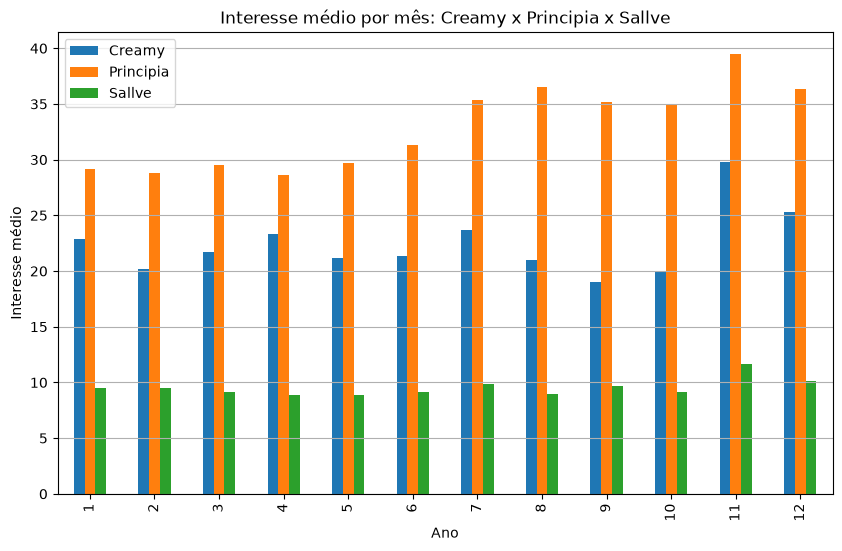

In [12]:
media_mes.plot(kind= "bar", figsize=(10,6))

plt.title("Interesse médio por mês: Creamy x Principia x Sallve")
plt.xlabel("Ano")
plt.ylabel("Interesse médio")
plt.grid(True, axis="y")
plt.show()

Novembro é o mês de maior interesse nas três marcas, provavelmente puxado pela Black Friday. No caso da Principia, esse patamar elevado não se limita a novembroo interesse já se mantém mais alto durante todo o segundo semestre, sugerindo um efeito mais amplo do que só o evento pontual.

### 3 - Quais consultas relacionadas aparecem para cada marca, e o que elas revelam sobre o tipo de busca (produto/ingrediente, opinião pré-compra ou comparação com concorrentes)?

In [13]:
df_freq_creamy = pd.read_csv("data/consultas_frequentes_creamy.csv")
df_freq_principia = pd.read_csv("data/consultas_frequentes_principia.csv")
df_freq_sallve = pd.read_csv("data/consultas_frequentes_sallve.csv")

df_alta_creamy = pd.read_csv("data/consultas_alta_creamy.csv")
df_alta_principia = pd.read_csv("data/consultas_alta_principia.csv")
df_alta_sallve = pd.read_csv("data/consultas_alta_sallve.csv")

In [14]:
df_freq_creamy["marca"] = "Creamy"
df_freq_creamy["tipo"] = "frequente"

df_freq_principia["marca"] = "Principia"
df_freq_principia["tipo"] = "frequente"

df_freq_sallve["marca"] = "Sallve"
df_freq_sallve["tipo"] = "frequente"

df_alta_creamy["marca"] = "Creamy"
df_alta_creamy["tipo"] = "alta"

df_alta_principia["marca"] = "Principia"
df_alta_principia["tipo"] = "alta"

df_alta_sallve["marca"] = "Sallve"
df_alta_sallve["tipo"] = "alta"

df_consultas = pd.concat([
    df_freq_creamy, df_freq_principia, df_freq_sallve,
    df_alta_creamy, df_alta_principia, df_alta_sallve
], ignore_index=True)

df_consultas

,query,search interest,increase percent,marca,tipo
0,skincare creamy,100,1.900%,Creamy,frequente
1,creamy skincare,96,1.900%,Creamy,frequente
2,hidratante creamy,87,3.100%,Creamy,frequente
3,creamy hidratante,87,2.700%,Creamy,frequente
4,retinol creamy,71,Breakout,Creamy,frequente
...,...,...,...,...,...
295,sallve serum uniformizador,3,Breakout,Sallve,alta
296,serum uniformizador sallve,3,Breakout,Sallve,alta
297,ácido salicílico,3,Breakout,Sallve,alta
298,hidratante renovador corporal sallve,3,Breakout,Sallve,alta


In [15]:
df_consultas[df_consultas["query"].str.contains("cupom")]

,query,search interest,increase percent,marca,tipo
33,creamy cupom,25,900%,Creamy,frequente
36,cupom creamy,24,700%,Creamy,frequente
92,principia cupom,19,Breakout,Principia,frequente
93,cupom principia,18,Breakout,Principia,frequente
114,sallve cupom,20,-2%,Sallve,frequente
118,cupom sallve,19,-6%,Sallve,frequente
240,principia cupom,19,Breakout,Principia,alta
241,cupom principia,18,Breakout,Principia,alta


In [16]:
df_consultas[df_consultas["query"].str.contains("resenha|é bom|vale a pena")]

,query,search interest,increase percent,marca,tipo
86,principia é bom,21,1.450%,Principia,frequente
134,sallve resenha,13,-50%,Sallve,frequente


In [17]:
df_consultas[(df_consultas["marca"] == "Creamy") & (df_consultas["query"].str.contains("principia|sallve"))]

,query,search interest,increase percent,marca,tipo
8,principia,67,Breakout,Creamy,frequente
32,sallve,26,Breakout,Creamy,frequente
153,principia,67,Breakout,Creamy,alta
163,sallve,26,Breakout,Creamy,alta
194,principia ou creamy,6,Breakout,Creamy,alta
195,retinol principia,6,Breakout,Creamy,alta
197,vitamina c principia,6,Breakout,Creamy,alta


In [18]:
df_consultas[(df_consultas["marca"] == "Sallve") & (df_consultas["query"].str.contains("creamy|principia"))]

,query,search interest,increase percent,marca,tipo
108,creamy,28,Breakout,Sallve,frequente
116,principia,19,Breakout,Sallve,frequente
250,creamy,28,Breakout,Sallve,alta
252,principia,19,Breakout,Sallve,alta


In [19]:
df_consultas[(df_consultas["marca"] == "Principia") & (df_consultas["query"].str.contains("creamy|sallve"))]

,query,search interest,increase percent,marca,tipo
79,creamy,38,Breakout,Principia,frequente
229,creamy,38,Breakout,Principia,alta


Cupom apareceu nas três marcas, então isso não separa ninguém. Já "é bom" e "resenha" só aparecem pra Principia e Sallve, na Creamy isso não apareceu. Na comparação direta entre marcas, só achei "Principia ou Creamy" do lado da Creamy, e nunca o contrário. Ou seja, o público de Creamy não verbaliza dúvida do tipo "será que é bom", mas ainda está comparando com a concorrente antes de decidir.

### 4 - Quais regiões possuem maior interesse por cada marca, e existe uma concentração geográfica diferente entre elas?

In [21]:
df_regioes = pd.read_csv("data/interesse_por_subregião.csv")
df_regioes

,Region,principia,sallve,creamy
0,Sergipe,59,13,28
1,Bahia,58,13,29
2,Alagoas,58,12,30
3,Paraíba,58,10,32
4,Piauí,57,11,32
5,Maranhão,57,10,33
6,Pernambuco,56,13,31
7,Espírito Santo,56,12,32
8,Minas Gerais,56,12,32
9,Rio de Janeiro,54,16,30


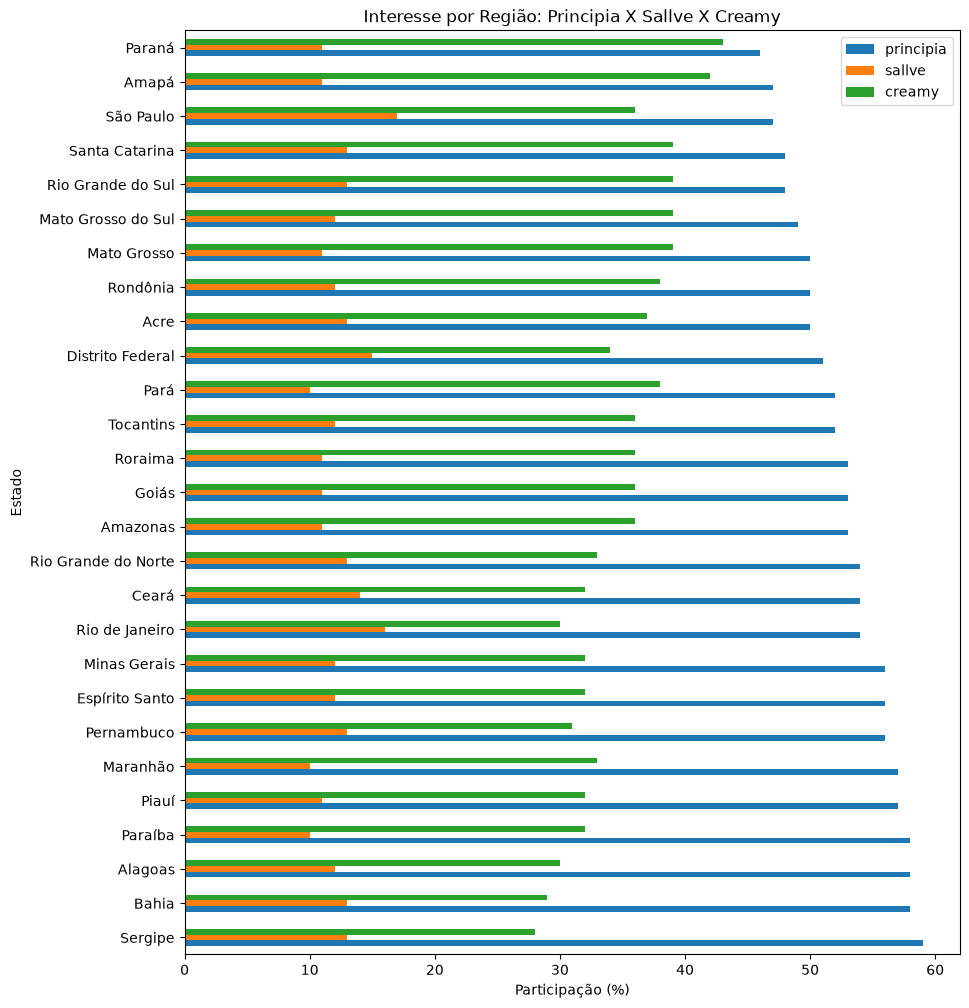

In [22]:
df_regioes.set_index("Region").plot(kind="barh", figsize=(10, 12))
plt.title("Interesse por Região: Principia X Sallve X Creamy")
plt.xlabel("Participação (%)")
plt.ylabel("Estado")
plt.show()

A Principia lidera a participação de interesse em todos os estados, mas com foco maior nas regiões Norte e Nordeste. A Creamy, por outro lado, se concentra mais nas regiões Sul e Sudeste. Já a Sallve tem a menor participação no geral, com picos pontuais no Rio de Janeiro, São Paulo e Distrito Federal, sugerindo uma presença mais concentrada nos grandes centros urbanos.

# CONCLUSÃO

Principia aparece como a marca mais buscada em quase tudo, liderando todos os estados e crescendo sem parar. Ela é a marca mais consistentemente em fase de expansão acelerada.
A Creamy cresceu até 2024 e depois estagnou, domina as regiões Sul e Sudeste, e é a única das três sem sinal de dúvida/review nas buscas,  o que sugere um público mais formado, que já decidiu.
Sallve é a menor em quase tudo, mas tem um padrão próprio, é mais concentrada em centros urbanos, como Rio de Janeiro, São Paulo e Distrito Federal.